In [1]:
print("hi")

hi


In [28]:
import os
from torchvision import datasets, transforms

# Define image transformations
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor()
# ])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Paths
train_dir = "../data/train"
test_dir = "../data/test"

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

# Train info
print("=== TRAIN DATA ===")
print("Number of classes:", len(train_dataset.classes))
print("Classes:", train_dataset.classes)
print("Total train images:", len(train_dataset))

# Test info
print("\n=== TEST DATA ===")
print("Number of classes:", len(test_dataset.classes))
print("Classes:", test_dataset.classes)
print("Total test images:", len(test_dataset))

=== TRAIN DATA ===
Number of classes: 23
Classes: ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Nail Fungus and other Nail Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors', 'Systemic Disease', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives', 'Vascular Tumors', 'Vasculitis Photos', 'Warts Molluscum and other Viral Infections']
Total train images: 15557

=== TEST DATA

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..1.5810429].


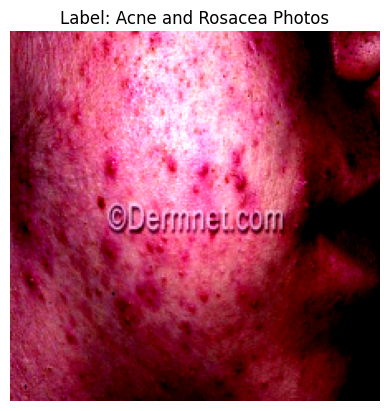

In [29]:
# visualize the datasetsimport matplotlib.pyplot as plt
import matplotlib.pyplot as plt
# Get one sample
image, label = train_dataset[0]

# Convert tensor to image for display
image = image.permute(1, 2, 0)  # (C,H,W) → (H,W,C)

plt.imshow(image)
plt.title(f"Label: {class_names[label]}")
plt.axis('off')
plt.show()

In [30]:
# creating the batch size of the dataset
from torch.utils.data import DataLoader

# Create batches
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Check one batch
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])


In [31]:
# Building the First Vision Model (Baseline CNN)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models


# class SimpleCNN(nn.Module):
#     def __init__(self, num_classes):
#         super(SimpleCNN, self).__init__()
        
#         self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
#         self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
#         self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        
#         self.pool = nn.MaxPool2d(2, 2)
        
#         self.fc1 = nn.Linear(64 * 28 * 28, 128)
#         self.fc2 = nn.Linear(128, num_classes)
        
#     def forward(self, x):
#         x = self.pool(F.relu(self.conv1(x)))  # 224 → 112
#         x = self.pool(F.relu(self.conv2(x)))  # 112 → 56
#         x = self.pool(F.relu(self.conv3(x)))  # 56 → 28
        
#         x = x.view(x.size(0), -1)  # flatten
        
#         x = F.relu(self.fc1(x))
#         x = self.fc2(x)
        
#         return x

# # Initialize model
# model = SimpleCNN(num_classes=len(train_dataset.classes))

model = models.efficientnet_b0(pretrained=True)

# Replace final layer for your 23 classes
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(train_dataset.classes))

model = model.to(device)

print(model)

# print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [32]:
# Training Setup (Loss + Optimizer)
import torch.optim as optim
# Loss function (classification)
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# One Training Epoch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 1

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

In [22]:
# Evaluate on Test Data
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 28.01%
